In [14]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import holidays
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("Libraries imported!")

Libraries imported!


In [15]:
# Load data
patients = pd.read_csv('../data/patients.csv', parse_dates=['admission_datetime'])

# Create daily admissions dataset
patients['date'] = patients['admission_datetime'].dt.date
daily_counts = patients.groupby('date').size().reset_index(name='admissions')
daily_counts['date'] = pd.to_datetime(daily_counts['date'])
daily_counts = daily_counts.sort_values('date').reset_index(drop=True)

print(f"Daily admissions data from {daily_counts['date'].min().date()} to {daily_counts['date'].max().date()}")
print(f"Total days: {len(daily_counts)}")
daily_counts.head()

Daily admissions data from 2023-01-01 to 2023-12-30
Total days: 364


,date,admissions
0,2023-01-01,8
1,2023-01-02,11
2,2023-01-03,21
3,2023-01-04,15
4,2023-01-05,8


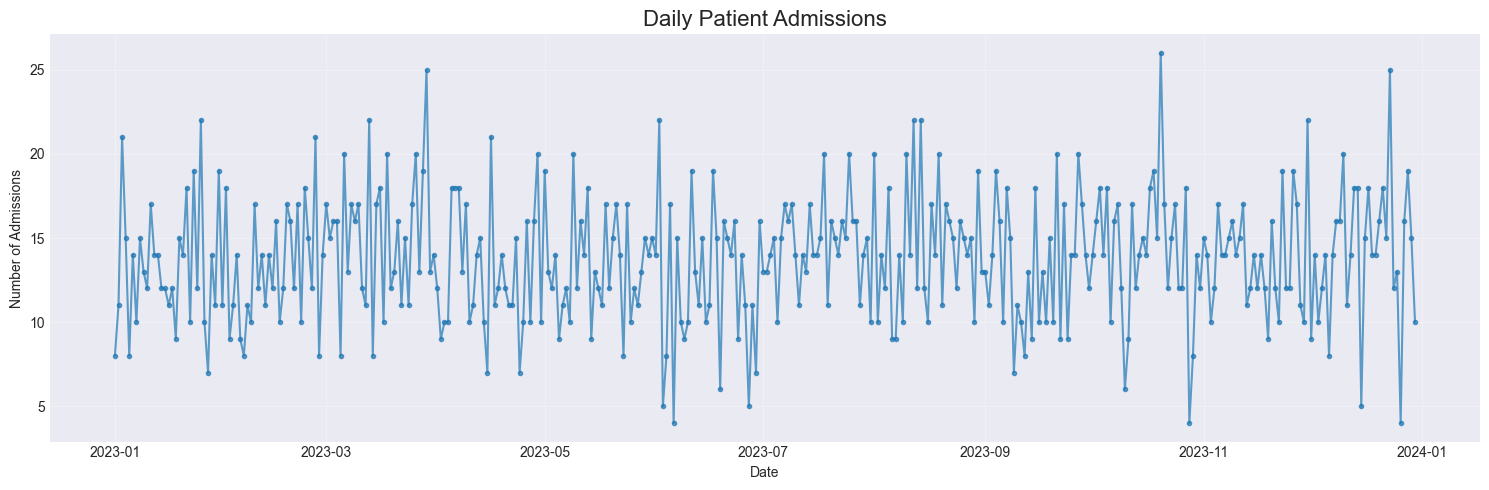

In [16]:
# Plot daily admissions
plt.figure(figsize=(15,5))
plt.plot(daily_counts['date'], daily_counts['admissions'], marker='.', linestyle='-', alpha=0.7)
plt.title('Daily Patient Admissions', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Number of Admissions')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# Feature Engineering
print("Creating features...")

# Date features
daily_counts['dayofweek'] = daily_counts['date'].dt.dayofweek
daily_counts['month'] = daily_counts['date'].dt.month
daily_counts['day'] = daily_counts['date'].dt.day
daily_counts['is_weekend'] = (daily_counts['dayofweek'] >= 5).astype(int)
daily_counts['quarter'] = daily_counts['date'].dt.quarter

# Holiday features
us_holidays = holidays.US()
daily_counts['is_holiday'] = daily_counts['date'].apply(lambda x: 1 if x in us_holidays else 0)

# Lag features (previous days)
daily_counts['lag_1'] = daily_counts['admissions'].shift(1)
daily_counts['lag_2'] = daily_counts['admissions'].shift(2)
daily_counts['lag_3'] = daily_counts['admissions'].shift(3)
daily_counts['lag_7'] = daily_counts['admissions'].shift(7)  # same day last week
daily_counts['lag_14'] = daily_counts['admissions'].shift(14)  # two weeks ago

# Rolling averages
daily_counts['rolling_mean_7'] = daily_counts['admissions'].rolling(window=7).mean()
daily_counts['rolling_mean_30'] = daily_counts['admissions'].rolling(window=30).mean()

# Drop NaN values from lag features
daily_counts = daily_counts.dropna().reset_index(drop=True)

print(f"Final dataset shape: {daily_counts.shape}")
print("\nFeatures created:")
print(daily_counts.columns.tolist())
daily_counts.head()

Creating features...
Final dataset shape: (335, 15)

Features created:
['date', 'admissions', 'dayofweek', 'month', 'day', 'is_weekend', 'quarter', 'is_holiday', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_mean_30']


,date,admissions,dayofweek,month,day,is_weekend,quarter,is_holiday,lag_1,lag_2,lag_3,lag_7,lag_14,rolling_mean_7,rolling_mean_30
0,2023-01-30,19,0,1,30,0,1,0,11.0,14.0,7.0,19.0,11.0,13.571429,13.300000
1,2023-01-31,11,1,1,31,0,1,0,19.0,11.0,14.0,12.0,12.0,13.428571,13.400000
2,2023-02-01,18,2,2,1,0,1,0,11.0,19.0,11.0,22.0,9.0,12.857143,13.633333
3,2023-02-02,9,3,2,2,0,1,0,18.0,11.0,19.0,10.0,15.0,12.714286,13.233333
4,2023-02-03,11,4,2,3,0,1,0,9.0,18.0,11.0,7.0,14.0,13.285714,13.100000


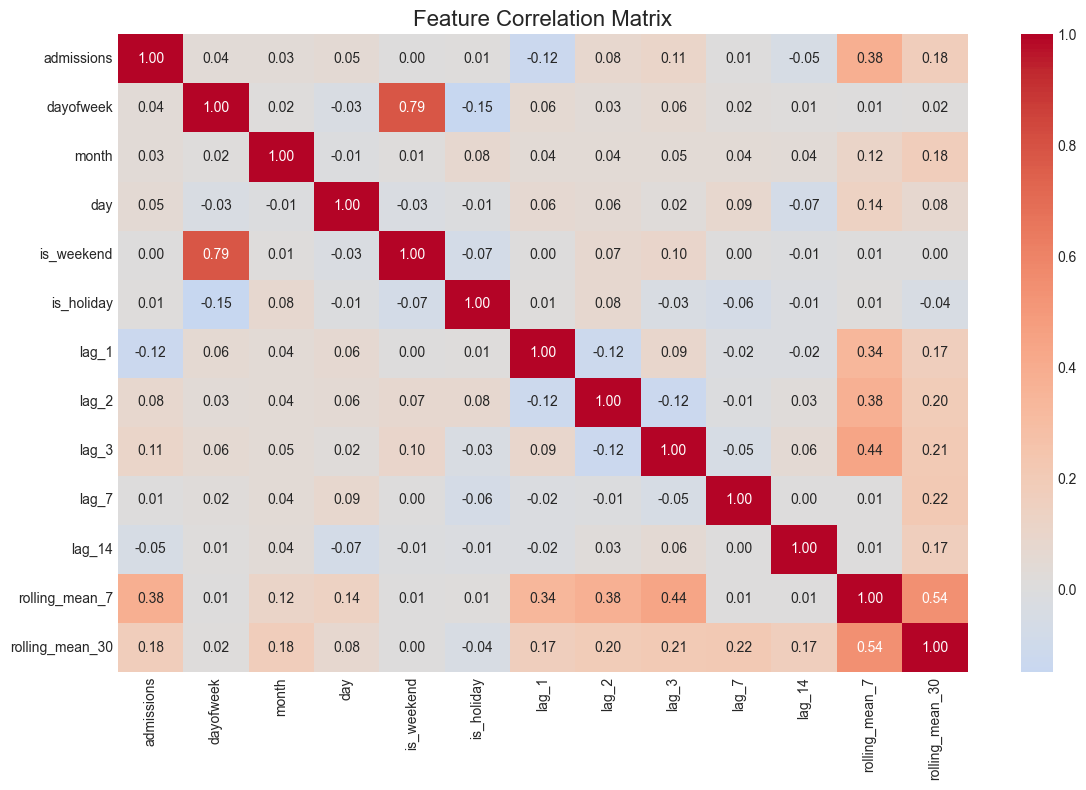

In [18]:
# Correlation analysis
corr_features = ['admissions', 'dayofweek', 'month', 'day', 'is_weekend', 'is_holiday', 
                 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_mean_30']

plt.figure(figsize=(12,8))
correlation_matrix = daily_counts[corr_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

In [19]:
# Prepare features for modeling
feature_columns = ['dayofweek', 'month', 'day', 'is_weekend', 'is_holiday', 
                   'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 
                   'rolling_mean_7', 'rolling_mean_30']

X = daily_counts[feature_columns]
y = daily_counts['admissions']

# Train/test split (time-based - use last 20% for testing)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training set: {len(X_train)} days")
print(f"Test set: {len(X_test)} days")
print(f"\nTraining period: {daily_counts['date'].iloc[0].date()} to {daily_counts['date'].iloc[split_idx-1].date()}")
print(f"Testing period: {daily_counts['date'].iloc[split_idx].date()} to {daily_counts['date'].iloc[-1].date()}")

Training set: 268 days
Test set: 67 days

Training period: 2023-01-30 to 2023-10-24
Testing period: 2023-10-25 to 2023-12-30


In [20]:
# Train Random Forest model
print("Training Random Forest model...")
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Evaluate
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\n" + "="*50)
print("MODEL PERFORMANCE")
print("="*50)
print(f"Training MAE: {train_mae:.2f} admissions")
print(f"Testing MAE: {test_mae:.2f} admissions")
print(f"Training R²: {train_r2:.3f}")
print(f"Testing R²: {test_r2:.3f}")
print("="*50)

Training Random Forest model...

MODEL PERFORMANCE
Training MAE: 1.43 admissions
Testing MAE: 2.78 admissions
Training R²: 0.769
Testing R²: 0.107


In [21]:
# Cross-validation
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
cv_mae = -cv_scores

print("Cross-Validation Results (5-fold):")
print(f"MAE scores: {[f'{score:.2f}' for score in cv_mae]}")
print(f"Average MAE: {cv_mae.mean():.2f} (+/- {cv_mae.std()*2:.2f})")

Cross-Validation Results (5-fold):
MAE scores: ['2.55', '3.47', '2.96', '2.76', '2.94']
Average MAE: 2.94 (+/- 0.61)


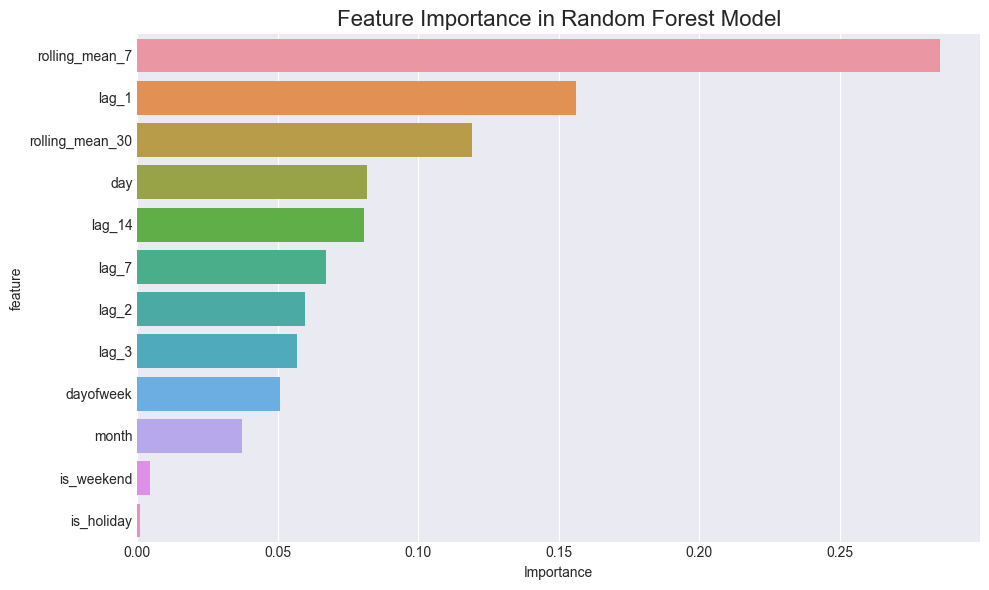


Top 5 Most Important Features:
        feature  importance
 rolling_mean_7    0.285647
          lag_1    0.156156
rolling_mean_30    0.119090
            day    0.081742
         lag_14    0.080751


In [22]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Feature Importance in Random Forest Model', fontsize=16)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(feature_importance.head().to_string(index=False))

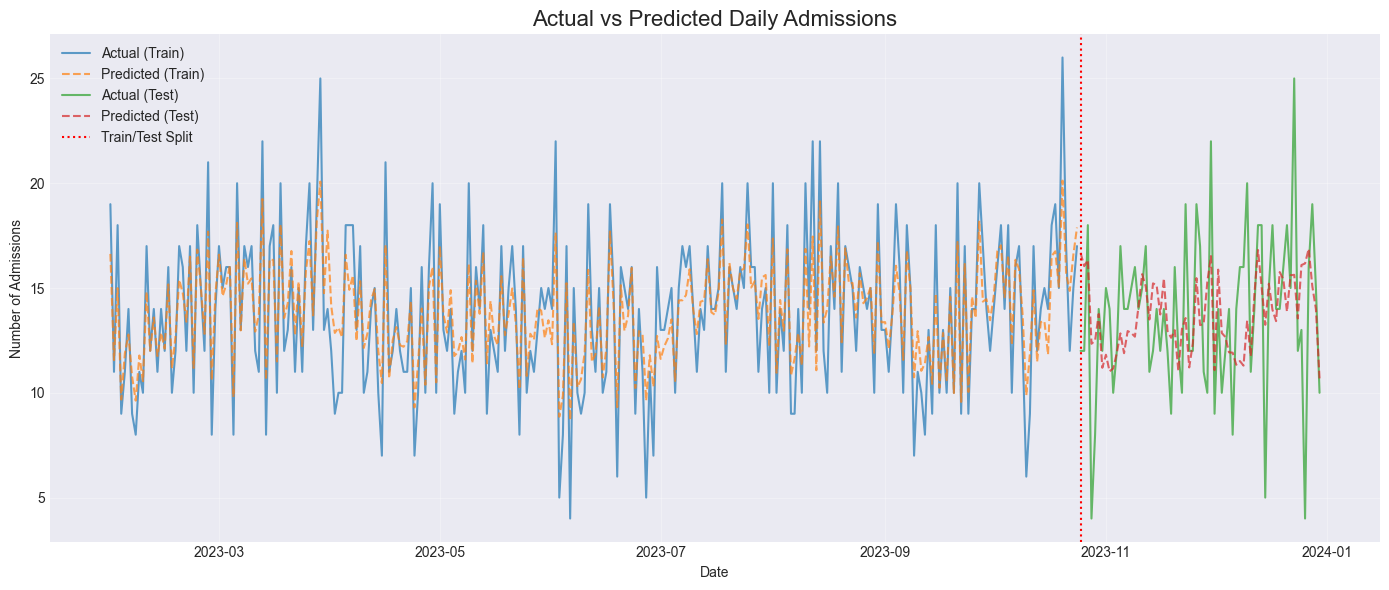

In [23]:
# Actual vs Predicted plot
plt.figure(figsize=(14,6))

# Training period
train_dates = daily_counts['date'].iloc[:split_idx]
test_dates = daily_counts['date'].iloc[split_idx:]

plt.plot(train_dates, y_train, label='Actual (Train)', alpha=0.7)
plt.plot(train_dates, y_train_pred, label='Predicted (Train)', alpha=0.7, linestyle='--')
plt.plot(test_dates, y_test, label='Actual (Test)', alpha=0.7)
plt.plot(test_dates, y_test_pred, label='Predicted (Test)', alpha=0.7, linestyle='--')

plt.axvline(x=test_dates.iloc[0], color='red', linestyle=':', label='Train/Test Split')
plt.title('Actual vs Predicted Daily Admissions', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Number of Admissions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

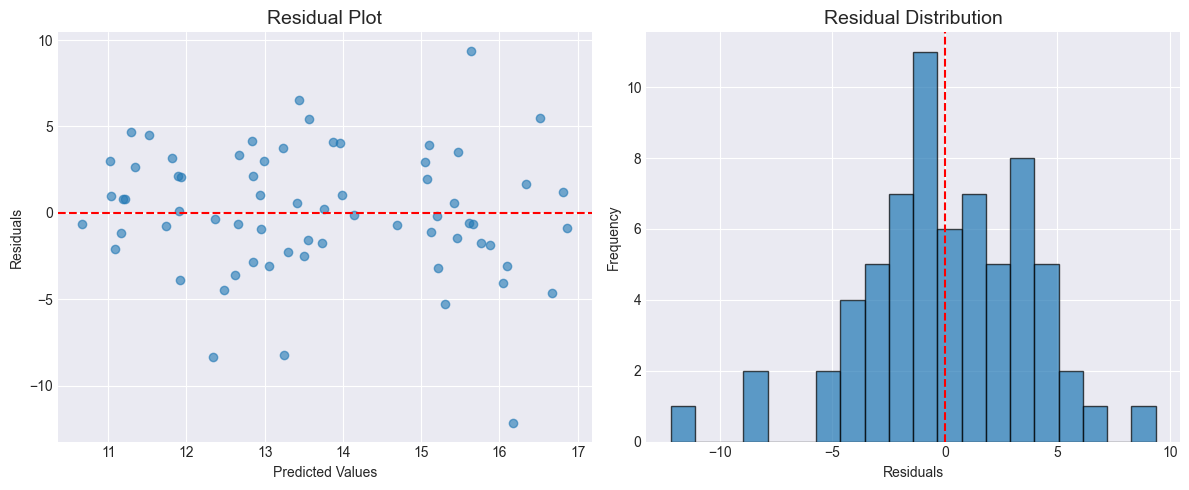

Residuals - Mean: 0.06, Std: 3.65


In [24]:
# Residual analysis
residuals = y_test - y_test_pred

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot', fontsize=14)

plt.subplot(1,2,2)
plt.hist(residuals, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residual Distribution', fontsize=14)
plt.axvline(x=0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

print(f"Residuals - Mean: {residuals.mean():.2f}, Std: {residuals.std():.2f}")

In [25]:
# Calculate required staff based on predictions
# Using average patient-to-staff ratio from EDA
avg_patient_to_staff = 4.5  # from our EDA

# Create predictions dataframe
predictions_df = pd.DataFrame({
    'date': test_dates,
    'actual_admissions': y_test.values,
    'predicted_admissions': y_test_pred,
    'required_staff': np.ceil(y_test_pred / avg_patient_to_staff)
})

print("Staffing Recommendations for Test Period:")
print(predictions_df.head(10).to_string(index=False))

# Summary statistics
print("\n" + "="*50)
print("STAFFING REQUIREMENTS SUMMARY")
print("="*50)
print(f"Average daily admissions (actual): {predictions_df['actual_admissions'].mean():.1f}")
print(f"Average daily admissions (predicted): {predictions_df['predicted_admissions'].mean():.1f}")
print(f"Average required staff per day: {predictions_df['required_staff'].mean():.1f}")
print(f"Min required staff: {predictions_df['required_staff'].min()}")
print(f"Max required staff: {predictions_df['required_staff'].max()}")
print("="*50)

Staffing Recommendations for Test Period:
      date  actual_admissions  predicted_admissions  required_staff
2023-10-25                 12             16.669147             4.0
2023-10-26                 12             16.042616             4.0
2023-10-27                 18             16.334911             4.0
2023-10-28                  4             12.338263             3.0
2023-10-29                  8             12.485279             3.0
2023-10-30                 14             13.759105             4.0
2023-10-31                 12             11.194513             3.0
2023-11-01                 15             11.815219             3.0
2023-11-02                 14             11.023235             3.0
2023-11-03                 10             11.161324             3.0

STAFFING REQUIREMENTS SUMMARY
Average daily admissions (actual): 13.7
Average daily admissions (predicted): 13.7
Average required staff per day: 3.5
Min required staff: 3.0
Max required staff: 4.0


In [26]:
# Save predictions to CSV
predictions_df.to_csv('../data/staffing_predictions.csv', index=False)
print("Predictions saved to '../data/staffing_predictions.csv'")

Predictions saved to '../data/staffing_predictions.csv'
